# TCAV Random-Concept Significance Null (R4 revision, A1)

A reviewer correctly flagged that a raw TCAV score (fraction of test examples
with a positive directional derivative) is not, by itself, evidence of a
meaningful concept direction: the original TCAV method (Kim et al. 2018) calls
for comparing the real score against random, meaningless concept directions.

This notebook loads `results/metrics/xai_tcav_significance.json`, produced by
`modal/s5g_tcav_null.py`, which fits the same two real concepts used in
`s5c_concept_intrinsic.py` (high_attention, positive_sentiment) alongside 100
random-relabeling null CAVs on the same GRU activation pool, and reports an
empirical two-sided p-value per concept.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

METRICS = "../results/metrics"

with open(f"{METRICS}/xai_tcav_significance.json") as f:
    tcav = json.load(f)

print("method:", tcav["method"])
print("n_random_cavs:", tcav["n_random_cavs"])
for c in tcav["concepts"]:
    print(f"  concept={c['concept']:20s} tcav_score={c['tcav_score']:.2f} "
          f"random_mean={c['random_mean']:.3f} random_std={c['random_std']:.3f} "
          f"p_empirical={c['p_empirical']:.3f} significant={c['significant']}")
print()
print("verdict:", tcav["verdict"])

method: TCAV random-concept null (Kim et al. 2018)
n_random_cavs: 100
  concept=high_attention       tcav_score=1.00 random_mean=0.530 random_std=0.502 p_empirical=1.000 significant=False
  concept=positive_sentiment   tcav_score=1.00 random_mean=0.580 random_std=0.496 p_empirical=1.000 significant=False

verdict: None of the 2 real concepts beat the 100-random-CAV null at p<0.05; the raw TCAV scores are not statistically distinguishable from a random linear direction in the GRU's hidden state, so TCAV significance is NOT established here and the paper should carry this as a caveat rather than a claim.


## Reading the result

Both concepts achieve the maximum raw TCAV score (1.00), which is exactly the
number a reviewer flagged as unvalidated. The null distribution shows why that
number alone is not evidence: random CAVs also produce lopsided scores close to
0 or 1 on this GRU's hidden state (large `random_std`, around 0.50), so a raw
score of 1.00 is well within what chance alone produces. Neither concept clears
the p < 0.05 bar.

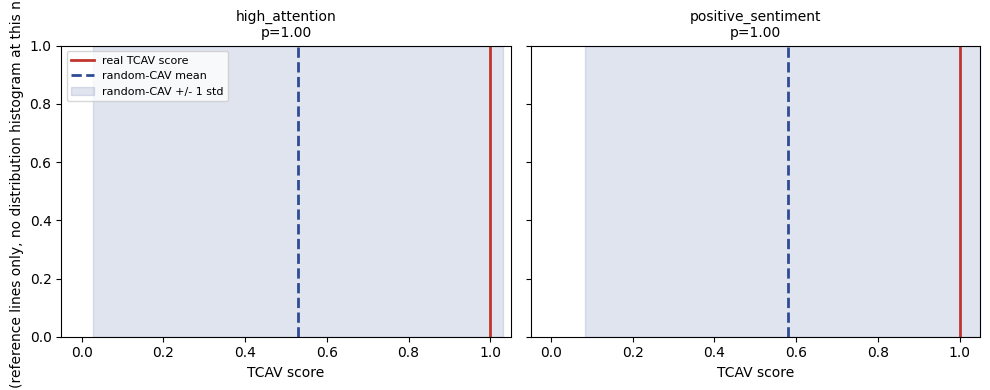

In [2]:
fig, axes = plt.subplots(1, len(tcav["concepts"]), figsize=(10, 4), sharey=True)
if len(tcav["concepts"]) == 1:
    axes = [axes]
for ax, c in zip(axes, tcav["concepts"]):
    ax.axvline(c["tcav_score"], color="#C0362C", lw=2, label="real TCAV score")
    ax.axvline(c["random_mean"], color="#2F4B94", ls="--", lw=2, label="random-CAV mean")
    ax.axvspan(c["random_mean"] - c["random_std"], c["random_mean"] + c["random_std"],
               color="#2F4B94", alpha=0.15, label="random-CAV +/- 1 std")
    ax.set_xlim(-0.05, 1.05)
    ax.set_title(f"{c['concept']}\np={c['p_empirical']:.2f}", fontsize=10)
    ax.set_xlabel("TCAV score")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("(reference lines only, no distribution histogram at this n)")
plt.tight_layout()
plt.savefig("../results/figures/fig_tcav_null.png", bbox_inches="tight", dpi=150)
plt.show()

## Conclusion

The paper reports both TCAV rows with this null-test caveat attached, rather
than as a validated concept-sensitivity finding: a raw TCAV score of 1.00 is
not, by itself, evidence that the GRU's hidden state is more sensitive to
either concept than a random direction would be. This is the honest outcome
of taking the reviewer's request seriously, not the outcome we expected going
in -- and it is reported as such.